# DAF-09: Clean It, One Decision Per Fault, Then Score Again

In DAF-08 Asha went through R K Puram's raw data like a detective. She found
four faults, and she also proved two scary-looking things were **not** faults
(the 1,753 µg/m³ Diwali night, and the single sensor).

Her friend Ravi says: *"Great, now just clean it. Drop the outliers, fill the
gaps, done."*

Asha tried that quickly on paper, and saw the problem:

- "Drop the outliers" with a 3-standard-deviation rule **deletes Diwali**, the
  one night she most needs a warning for.
- "Fill the gaps" across the 10-day January outage **makes up 241 hours** of
  air that nobody measured.
- A month later, when the MAE changes, she **cannot say which fix caused it**.

So Asha changes the rule. Every fault gets **one written decision**: what she
did, why, and how many rows it changed. "Leave it alone" counts as a decision
too. Then she runs the DAF-07 model again, on the same cut date, to see
whether cleaning helped at all.

> This notebook is the record of those decisions. The markdown explains each
> step. **The code cells are yours.** Each one has hints only.

## 0. What this ticket asks, in one picture

```text
                 DAF-08 found the faults             DAF-09 (this notebook)
                 ───────────────────────             ──────────────────────
data/raw/  ──►  docs/data_faults.md          ──►  one decision per fault
(never              Fault 1  duplicates                    │
 touched)           Fault 2  missing hours                 ▼
                    Fault 3  invalid-day clusters   clean_pm25()   one place, fixed order
                    Fault 4  late weather params           │
                    Not a fault: Diwali, sensor            ▼
                                                   rebuild daily table   (same rules as DAF-05)
                                                           │
                                                           ▼
                                           data/interim/daily_17_clean.csv
                                                           │
                                                           ▼
                                           same DAF-07 Ridge pipeline, same cut date
                                                           │
                                                           ▼
                                           reports/experiments.csv   ← a new row next to DAF-07
```

**Done means** (the acceptance criteria, in plain words):

| # | Criterion | Where you prove it in this notebook |
|---|---|---|
| 1 | Every fault has a decision, including "leave it" | Step 2 decision log |
| 2 | Each decision says how many rows it changed | Step 3, one count per fault |
| 3 | `data/raw/` is unchanged | Step 1 fingerprint, checked again in Step 8 |
| 4 | Poor-or-worse days counted **before and after** cleaning | Step 5 |
| 5 | The new MAE and recall are in the log, next to the DAF-07 row | Step 7 |

## The five treatments, as pictures

Every decision you make is one of these five. Each has a danger.

```text
Leave it              Drop the rows          Cap it                 Interpolate a gap      Mark it
─────────             ─────────────          ──────                 ─────────────────      ───────
   ▲                       ▲                 cap ─ ─ ─ ─ ─ ─           ● ●  ○  ● ●          ● ● ● ● ●
 ● ● ●                 ●   ✗   ●             ●   ▲   ●                      ↑               flag: 0 0 1 0 0
●     ●              ●           ●          ●   (cut)  ●             invented value
real, keep it        impossible + rare      real direction,          short hole only        can't decide yet
                                            wrong size
danger: model         danger: you drop the   danger: the cap is      danger: invented       danger: none,
learns odd things     very days that matter  a guess, write it down  readings if gap long   a flag is cheap
```

A useful question to ask for each fault:

> **Is this the sensor being wrong, or the air being unusual?**
> If the air is unusual, it is exactly what Asha needs to forecast. Keep it.

## Step 1. Start again from `data/raw/`, and fingerprint it first

### 😖 The problem

Asha already has `daily_17.csv`. Why not clean that?

Because it is **already squashed**. The 15-minute readings became hours, and
the hours became one number per day. A missing hour you want to fill is gone
by then. You can't un-average a day.

So cleaning starts from the raw files, and raw is **read-only**. Think of it
like a Kafka topic: you replay it as often as you like, but you never edit
it.

```text
data/raw/        (read-only, replayed)
    │
    ▼
 clean  ◄── all DAF-09 decisions happen here
    │
    ▼
data/interim/daily_17_clean.csv   (new file; daily_17.csv stays as it is)
```

### 💡 How do you prove raw was not touched?

A **fingerprint** (a hash) is a short code worked out from a file's bytes.
Change even one byte and the code comes out completely different. Take the
fingerprints now, and again at the very end of the notebook:

```text
start of notebook                    end of notebook
─────────────────                    ───────────────
location-17-20250219.csv.gz → 9f2c…    → 9f2c…   ✅ same
location-17-20250220.csv.gz → 11ab…    → 11ab…   ✅ same
...                                     ...
554 files                              554 files, all the same → raw untouched
```

This is acceptance criterion 3 (`data/raw/` is unchanged). The end-of-notebook
check comes in a later step. Here you only take the "before" fingerprint.

### What this step should print

| Check | Expected (from DAF-05 / DAF-08) |
|---|---|
| raw files fingerprinted | 554 |
| PM2.5 rows loaded | 44,139 |
| first timestamp | 2025-02-19 … +05:30 |
| last timestamp | 2026-09-12 (early morning) … +05:30 |

If your numbers differ, stop and find out why before cleaning anything.

In [1]:
# TODO 1a: paths
#   - project_root, raw_dir (location 17), interim_dir, reports_dir
#   - same style as 05_daily_table.ipynb (Path.cwd().parent)

# TODO 1b: fingerprint every raw file BEFORE anything else
#   - list every *.csv.gz under raw_dir (you did this in DAF-05)
#   - for each file, hash its bytes
#       look up: hashlib.md5(path.read_bytes()).hexdigest()
#   - store as a dict {file name: hash} called raw_fingerprint_before
#   - print how many files you fingerprinted, and one example (name → hash)

In [2]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
raw_dir = project_root / "data/raw/openaq/locationid=17"

files = sorted(raw_dir.rglob("*.csv.gz"))
print("Files found:", len(files))
print("First file:", files[0].name)
print("Last file:", files[-1].name)
print("Raw_dir",raw_dir)

Files found: 554
First file: location-17-20250219.csv.gz
Last file: location-17-20260911.csv.gz
Raw_dir /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/raw/openaq/locationid=17


In [3]:
# 1b: fingerprint every raw file BEFORE anything else reads them
import hashlib

# Key = path relative to raw_dir (e.g. "year=2025/month=02/location-17-20250219.csv.gz").
# The full relative path, not just the name, so two months can never collide on one key.
# Value = md5 of the file's bytes. Change one byte and the hash is completely different.
raw_fingerprint_before = {
    str(f.relative_to(raw_dir)): hashlib.md5(f.read_bytes()).hexdigest()
    for f in files
}

example_file, example_hash = next(iter(raw_fingerprint_before.items()))
print("Files fingerprinted:", len(raw_fingerprint_before))
print("Example:", example_file, "→", example_hash)

Files fingerprinted: 554
Example: year=2025/month=02/location-17-20250219.csv.gz → d728ee6e15ad2967b9daa3a2b644a8e2


In [4]:
# 1c: load every raw file, keep PM2.5 only (same as DAF-05 steps 1 and 2)
frames = [pd.read_csv(f, compression="gzip") for f in files]
print("Count of files ", len(frames))
raw_all = pd.concat(frames, ignore_index=True)

pm25_raw = raw_all[raw_all["parameter"] == "pm25"].copy()

# The text already carries "+05:30", so to_datetime keeps the IST offset
pm25_raw["datetime"] = pd.to_datetime(pm25_raw["datetime"])

# Cleaning only needs the time and the reading
pm25_raw = pm25_raw[["datetime", "value"]].sort_values("datetime").reset_index(drop=True)

print("All raw rows (every parameter):", len(raw_all))
print("PM2.5 rows:", len(pm25_raw))
print("Timezone:", pm25_raw["datetime"].dt.tz)
print("First timestamp:", pm25_raw["datetime"].min())
print("Last timestamp :", pm25_raw["datetime"].max())
pm25_raw.head()

Count of files  554
All raw rows (every parameter): 467816
PM2.5 rows: 44139
Timezone: UTC+05:30
First timestamp: 2025-02-19 01:45:00+05:30
Last timestamp : 2026-09-12 00:00:00+05:30


,datetime,value
0,2025-02-19 01:45:00+05:30,123.0
1,2025-02-19 02:00:00+05:30,97.0
2,2025-02-19 02:15:00+05:30,97.0
3,2025-02-19 02:30:00+05:30,97.0
4,2025-02-19 02:45:00+05:30,97.0


### 📊 Quick look: did every month arrive?

One simple chart before cleaning: **how complete each month of raw PM2.5
is.**

Raw row counts would mislead here. February 2025 starts on the 19th and
September 2026 ends on the 12th, so they'd look like outages when they're
only short months. So instead we compare each month with the number of
15-minute slots it *could* hold, and plot a percentage.

```text
coverage %
100 ┤
    ┤ ██ ██    ██ ██ ██ ██ ██       ██
 70 ┤-██-██-▄▄-██-██-██-██-██-▄▄-─-██-   ← dashed line
    ┤ ██ ██ ██ ██ ██ ██ ██ ██ ██    ██
    └──────────────────────────────────
      Feb Mar Apr ...        Jan ...
                             ↑ lowest bar = the 10-day outage
```

Red bars are months under 70%. This is only a check that the load worked.
It isn't a new finding: DAF-08 already measured the gaps.

         rows  possible  coverage_pct
2025-02   900       953          94.4
2025-03  2549      2976          85.7
2025-04  2006      2880          69.7
2025-05  2549      2976          85.7
2025-06  2266      2880          78.7
2025-07  2505      2976          84.2
2025-08  2550      2976          85.7
2025-09  2526      2880          87.7
2025-10  2548      2976          85.6
2025-11  2490      2880          86.5
2025-12  2523      2976          84.8
2026-01  1805      2976          60.7
2026-02  2050      2688          76.3
2026-03  2371      2976          79.7
2026-04  2468      2880          85.7
2026-05  2396      2976          80.5
2026-06  2188      2880          76.0
2026-07  2636      2976          88.6
2026-08  1982      2976          66.6
2026-09   831      1057          78.6


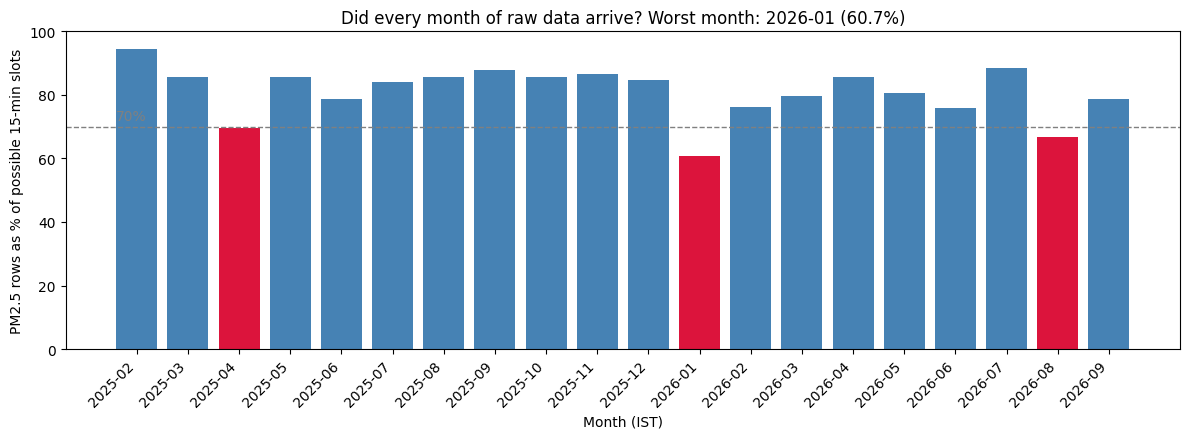

In [5]:
# 1d: how complete is each month of raw PM2.5?
import matplotlib.pyplot as plt

# tz_localize(None) keeps the IST clock time and drops the offset, so to_period
# groups by the Indian calendar month (to_period does not accept a timezone)
rows_per_month = (
    pm25_raw["datetime"].dt.tz_localize(None).dt.to_period("M").value_counts().sort_index()
)

# Every 15-minute slot between the first and last reading = what each month COULD hold.
# Using the real span means the half-months at both ends are judged fairly.
all_slots = pd.date_range(pm25_raw["datetime"].min(), pm25_raw["datetime"].max(), freq="15min")
slots_per_month = all_slots.tz_localize(None).to_period("M").value_counts().sort_index()

coverage = pd.DataFrame({"rows": rows_per_month, "possible": slots_per_month})
coverage["coverage_pct"] = (coverage["rows"] / coverage["possible"] * 100).round(1)
print(coverage.to_string())

worst = coverage["coverage_pct"].idxmin()
colors = ["crimson" if pct < 70 else "steelblue" for pct in coverage["coverage_pct"]]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(coverage.index.astype(str), coverage["coverage_pct"], color=colors)
ax.axhline(70, color="gray", linestyle="--", linewidth=1)
ax.text(-0.4, 71, "70%", color="gray", ha="left", va="bottom")
ax.set_ylim(0, 100)
ax.set_ylabel("PM2.5 rows as % of possible 15-min slots")
ax.set_xlabel("Month (IST)")
ax.set_title(f"Did every month of raw data arrive? Worst month: {worst} ({coverage.loc[worst, 'coverage_pct']}%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Step 2. The decision log: decide first, clean second

### Why this step?

Before we change any data, we write down **what** we will do and **why**.
Then nobody has to guess later.

We have 6 things to decide. For each one, answer **one simple question**.

---

### Fault 1: each hour has 4 readings, but 3 are copies

**What happened**

```text
10:00  → 80   (real reading)
10:15  → 80   (copy)
10:30  → 80   (copy)
10:45  → 80   (copy)
```

**Question:** DAF-05 takes the average of these 4 numbers. What is the
average of 80, 80, 80, 80?

**Think:** If the answer is still 80, the copies do no harm. Do we need to
change anything?

---

### Fault 2: some hours are missing

**What happened**

```text
Small hole:   10:00 → 80    11:00 → ???    12:00 → 90
Big hole:     10 whole days in January 2026 → nothing at all
```

**Question:** Would you fill the **small hole** with a guess? Would you fill
the **big hole** with a guess?

**Think:**
- Small hole: 80 before, 90 after, so 85 is a good guess.
- Big hole: 10 days with no readings. Any number we put there is made up.

---

### Fault 3: bad days come in groups (April 2025, January 2026, August 2026)

**What happened.** A day is "bad" (invalid) when it has fewer than 18 hours
of data. Many bad days fall in the same 3 months.

**Question:** Is this a new problem, or is it just Fault 2 (missing hours)
again?

**Think:** A day becomes bad **because** hours are missing. In Step 1 the
3 weak months were these same 3 months.

---

### Fault 4: wind and NOx data start late (October 2025)

**What happened.** `wind_speed`, `wind_direction` and `nox` have no data
before October 2025.

**Question:** Does our model (DAF-07) use wind or NOx today?

**Think:** The model uses PM2.5 only. If we don't use this data, is there
anything to clean?

---

### Not a fault: 1,753 on Diwali night

**What happened.** The highest reading is 1,753. It was Diwali night:
firecracker smoke.

**Question:** Is this the sensor being wrong, or the air really being that
bad?

**Think:** The air really was that bad. That's exactly the kind of day Asha
wants a warning for. If we delete it, the model never learns about it.

---

### Not a fault: one sensor the whole time

**What happened.** The same sensor was used from start to end.

**Question:** Is there anything to fix?

---

### The decisions

Treatment options: **leave it**, **fill small holes**, **drop**, **cap**,
**mark**.

| # | Fault | Treatment | Why | Rows changed |
|---|---|---|---|---|
| 1 | 3 of 4 readings are copies | **Leave it** | Most hours: the average of 80, 80, 80, 80 is still 80. In about 14% of hours the new reading arrives at :15, so the average mixes in a little of the previous hour. Step 3.1 shows this moves a daily mean by at most ~2 µg/m³, so we keep the DAF-05 average. | _Step 3_ |
| 2 | Missing hours (small holes + big hole) | **Fill small holes, up to 2 hours** | A 1–2 hour hole between two real readings is a fair straight-line guess. Longer holes stay empty: filling them would be making up air. **The 2 is a guess, not a measured number.** | _Step 3_ |
| 3 | Bad days come in groups | **Leave it** | This is Fault 2 seen at the day level. Filling small holes already helps. The 18-hour rule stays as it is (D-002). | _Step 3_ |
| 4 | Wind and NOx start late | **Leave it** | The model uses PM2.5 only. Nothing to clean yet. Look again when weather features arrive (DAF-13). | _Step 3_ |
| 5 | Diwali 1,753 | **Leave it** | Real smoke, not a sensor error. It's the day Asha most needs a warning for. | _Step 3_ |
| 6 | One sensor | **Leave it** | Nothing is wrong. | _Step 3_ |
| 7 | Sensor misbehaves 4–11 July 2025 (found in Step 6) | **Mark the week invalid** | Readings jump 1 → 432 → 17 and reach 1,356 in monsoon July. That's a broken sensor, not smoke. We don't trust any reading that week. | _Step 3_ |

Two decisions change the data: filling small holes, and removing the broken
week. Every other fault is left alone, on purpose, with a reason.

In [6]:
# Step 2: the decision log, in code.
# rows_changed stays None here. Step 3 counts it and fills it in.

FILL_LIMIT_HOURS = 2   # a guess, not a measured number: holes of 1-2 hours get filled, longer ones stay empty
BROKEN_SENSOR_DAYS = ("2025-07-04", "2025-07-11")   # Fault 7: first and last day we don't trust (both included)

decisions = [
    {"fault": "1. 3 of 4 readings are copies",
     "treatment": "leave it",
     "why": "average of copies is unchanged; ~14% of hours update at :15 but daily effect is small",
     "rows_changed": None},
    {"fault": "2. missing hours",
     "treatment": f"fill small holes (up to {FILL_LIMIT_HOURS} h)",
     "why": "short holes are a fair straight-line guess; long holes would be made-up air",
     "rows_changed": None},
    {"fault": "3. bad days come in groups",
     "treatment": "leave it",
     "why": "it is fault 2 at day level; the 18-hour rule stays (D-002)",
     "rows_changed": None},
    {"fault": "4. wind and nox start late",
     "treatment": "leave it",
     "why": "model uses PM2.5 only; revisit in DAF-13",
     "rows_changed": None},
    {"fault": "5. Diwali 1,753 (not a fault)",
     "treatment": "leave it",
     "why": "real smoke; the day Asha needs a warning for",
     "rows_changed": None},
    {"fault": "6. one sensor (not a fault)",
     "treatment": "leave it",
     "why": "nothing is wrong",
     "rows_changed": None},
    {"fault": "7. broken sensor week, 4-11 July 2025 (found in Step 6)",
     "treatment": "mark the week invalid",
     "why": "jumps like 1 -> 432 -> 17 and 1,356 in July: sensor error, not smoke",
     "rows_changed": None},
]

pd.DataFrame(decisions)

,fault,treatment,why,rows_changed
0,1. 3 of 4 readings are copies,leave it,average of copies is unchanged; ~14% of hours ...,None
1,2. missing hours,fill small holes (up to 2 h),short holes are a fair straight-line guess; lo...,None
2,3. bad days come in groups,leave it,it is fault 2 at day level; the 18-hour rule s...,None
3,4. wind and nox start late,leave it,model uses PM2.5 only; revisit in DAF-13,None
4,"5. Diwali 1,753 (not a fault)",leave it,real smoke; the day Asha needs a warning for,None
5,6. one sensor (not a fault),leave it,nothing is wrong,None
6,"7. broken sensor week, 4-11 July 2025 (found i...",mark the week invalid,"jumps like 1 -> 432 -> 17 and 1,356 in July: s...",None


## Step 3. Apply each decision, count what changed, and look

For each fault we do three small things:

```text
apply the decision  →  count how many rows changed  →  draw one picture
```

We never change `pm25_raw`. Each part works on its own copy.

### 3.1 Fault 1: copies inside each hour (decision: leave it)

**What we check.** Are the 4 readings in an hour really always the same
number? If they are, the average is the same, and leaving them is safe.

**What we found.** Mostly yes, but not always. In some hours the sensor's new
value arrives at **:15**, not at :00. The :00 slot still holds the **last
hour's** value:

```text
            normal hour                    "late" hour
16:00 → 42  ← new                17:00 → 34  ← old value from 16:xx
16:15 → 42                       17:15 → 29  ← new value arrives here
16:30 → 42                       17:30 → 29
16:45 → 42                       17:45 → 29
average = 42  ✅                 average = 30.25  (true value is 29)
```

In a late hour, the average is pulled a little toward the previous hour. The
question is whether this is big enough to matter for a **daily** number.

In [7]:
# 3.1: how often is an hour NOT four identical copies?
readings = pm25_raw.set_index("datetime")["value"]

values_per_hour = readings.resample("1h").nunique()    # how many DIFFERENT values in each hour
late_hours = (values_per_hour > 1).sum()
hours_with_data = (values_per_hour > 0).sum()

print("Hours with data:", hours_with_data)
print("Hours where all readings are the same:", (values_per_hour == 1).sum())
print(f"Late hours (value changes inside the hour): {late_hours} ({late_hours / hours_with_data:.1%})")

# Does it matter for the DAILY mean? Compare two ways of making an hour:
#   average of all readings (DAF-05)  vs  last reading of the hour (always the fresh one)
hourly_mean = readings.resample("1h").mean()
hourly_last = readings.resample("1h").last()
daily_gap = (hourly_mean.resample("D").mean() - hourly_last.resample("D").mean()).abs()

print(f"\nDaily mean difference, average vs last reading:")
print(f"  median {daily_gap.median():.2f}  |  95% of days under {daily_gap.quantile(0.95):.2f}  |  max {daily_gap.max():.2f} µg/m³")

# Decision was "leave it", so no rows change
decisions[0]["rows_changed"] = 0

Hours with data: 12165
Hours where all readings are the same: 10497
Late hours (value changes inside the hour): 1668 (13.7%)

Daily mean difference, average vs last reading:
  median 0.00  |  95% of days under 0.57  |  max 2.12 µg/m³


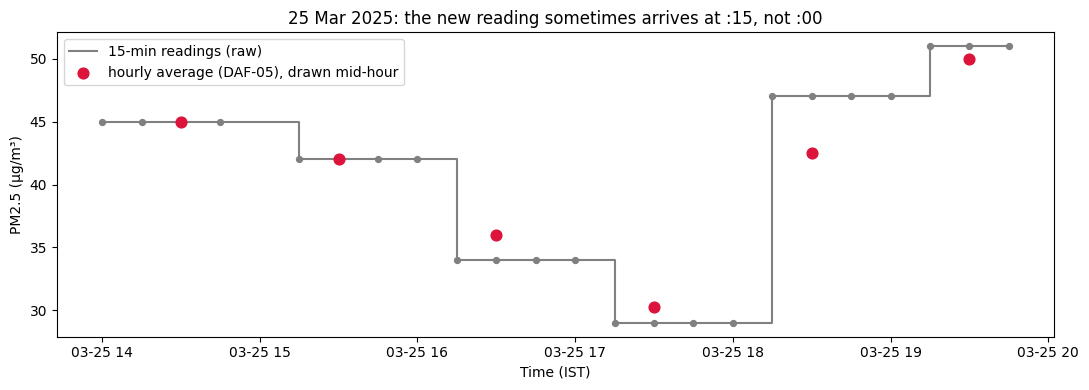

In [8]:
# 3.1 chart: one afternoon with both kinds of hour
import matplotlib.pyplot as plt

window = readings["2025-03-25 14:00":"2025-03-25 19:45"]
window_hourly = hourly_mean["2025-03-25 14:00":"2025-03-25 19:00"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.step(window.index, window.values, where="post", color="gray", label="15-min readings (raw)")
ax.scatter(window.index, window.values, color="gray", s=18)
ax.scatter(window_hourly.index + pd.Timedelta(minutes=30), window_hourly.values,
           color="crimson", s=60, zorder=3, label="hourly average (DAF-05), drawn mid-hour")
ax.set_title("25 Mar 2025: the new reading sometimes arrives at :15, not :00")
ax.set_xlabel("Time (IST)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

**What this means.** On most days the two methods agree exactly. The largest
gap is about 2 µg/m³ on a single day, which is small next to the model's
~15 µg/m³ error. So we **leave it** and keep the DAF-05 average. That keeps
this ticket's comparison fair: only one thing (filling holes) changes.

### 3.2 Fault 2: missing hours (decision: fill holes of 1–2 hours)

**Step A: measure the holes.** Turn the readings into hours (as in DAF-05).
An hour with no reading becomes empty (`NaN`). Then find each run of empty
hours in a row, and how long it is.

```text
hours:   80  84  NaN  92  95  NaN  NaN  NaN  ...  88
               └ 1 ┘          └──── 3 ────┘
               hole           hole
```

**Step B: fill only the short holes.** A hole of 1 or 2 hours gets a
straight line between its two neighbours. Anything longer stays empty.

```text
84 ● ○ ● 92      → ○ becomes 88       ✅ filled
84 ● ○ ○ ○ ● 92  → stays empty        ✗ too long (3 hours)
```

**The trap we avoid.** pandas' `interpolate(limit=2)` looks right but
isn't: on a 10-day hole it fills the **first 2 hours** and leaves the
rest. We want long holes left completely alone, so we measure each hole's
length first and fill only the short ones.

In [9]:
# 3.2 A: find every hole and its length
hourly = hourly_mean.copy()                    # same as DAF-05 step 3: hourly average

is_empty = hourly.isna()
run_id = (is_empty != is_empty.shift()).cumsum()           # new number each time empty/full switches
hole_lengths = is_empty.groupby(run_id).sum()               # length of every run
hole_lengths = hole_lengths[hole_lengths > 0]               # keep only the empty runs

print("Empty hours:", is_empty.sum(), "of", len(hourly))
print("Number of holes:", len(hole_lengths))

size_groups = pd.cut(hole_lengths, bins=[0, 1, 2, 3, 6, 24, 10_000],
                     labels=["1 h", "2 h", "3 h", "4–6 h", "7–24 h", "over 1 day"])
hole_table = size_groups.value_counts().sort_index().to_frame("holes")
hole_table["empty hours"] = hole_lengths.groupby(size_groups, observed=False).sum()
print(hole_table.to_string())

Empty hours: 1515 of 13680
Number of holes: 315
            holes  empty hours
value                         
1 h           178          178
2 h            41           82
3 h            23           69
4–6 h          25          118
7–24 h         39          505
over 1 day      9          563


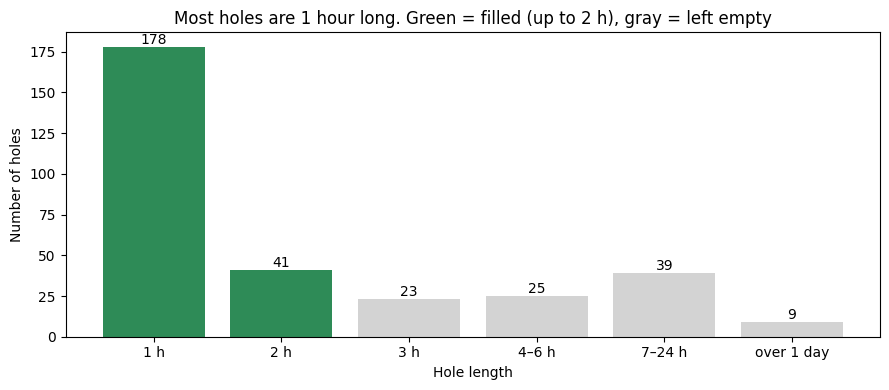

In [10]:
# 3.2 A chart: how many holes of each size, and which ones we fill
colors = ["seagreen" if label in ("1 h", "2 h") else "lightgray" for label in hole_table.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(hole_table.index.astype(str), hole_table["holes"], color=colors)
ax.bar_label(bars)
ax.set_title(f"Most holes are 1 hour long. Green = filled (up to {FILL_LIMIT_HOURS} h), gray = left empty")
ax.set_xlabel("Hole length")
ax.set_ylabel("Number of holes")
plt.tight_layout()
plt.show()

In [11]:
# 3.2 B: fill ONLY holes of FILL_LIMIT_HOURS or shorter
hole_length_per_hour = is_empty.groupby(run_id).transform("sum")    # each empty hour knows its hole's length
short_hole = is_empty & (hole_length_per_hour <= FILL_LIMIT_HOURS)

straight_line = hourly.interpolate(method="time", limit_area="inside")   # a guess for EVERY hole...
hourly_filled = hourly.where(~short_hole, straight_line)                 # ...but we only use it for short ones

filled_hours = (hourly.isna() & hourly_filled.notna()).sum()
print("Hours filled:", filled_hours)
print("Empty hours left:", hourly_filled.isna().sum())

# Check: every filled hour belongs to a short hole, and no long hole was touched
assert filled_hours == short_hole.sum()
assert hourly_filled[is_empty & ~short_hole].isna().all(), "a long hole was filled"

# Effect on days: the 18-hour rule from DAF-05
hours_before = hourly.resample("D").count()
hours_after = hourly_filled.resample("D").count()
print("\nInvalid days (under 18 hours) before:", (hours_before < 18).sum())
print("Invalid days (under 18 hours) after :", (hours_after < 18).sum())
print("Days that became valid:", ((hours_before < 18) & (hours_after >= 18)).sum())

decisions[1]["rows_changed"] = int(filled_hours)

Hours filled: 260
Empty hours left: 1255

Invalid days (under 18 hours) before: 83
Invalid days (under 18 hours) after : 76
Days that became valid: 7


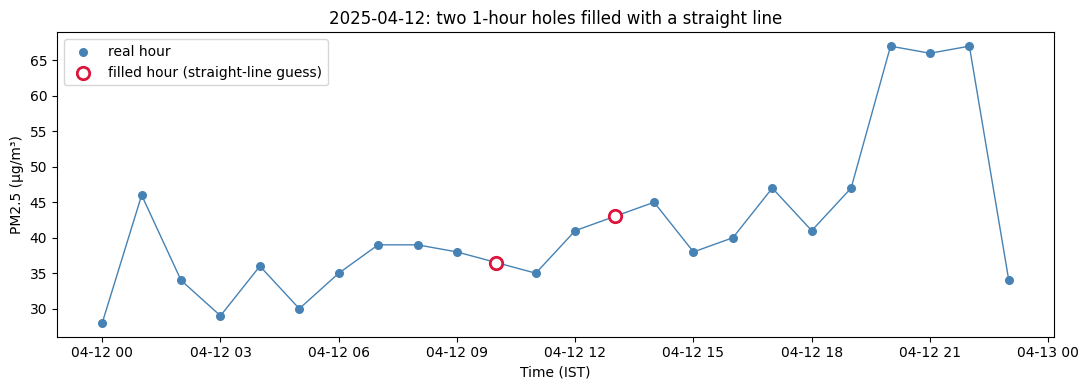

In [12]:
# 3.2 B chart: zoom into one day with filled holes; filled points must be easy to spot
day = "2025-04-12"
real = hourly[day]
guessed = hourly_filled[day][short_hole[day]]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly_filled[day].index, hourly_filled[day].values, color="steelblue", linewidth=1)
ax.scatter(real.index, real.values, color="steelblue", s=30, label="real hour")
ax.scatter(guessed.index, guessed.values, facecolors="white", edgecolors="crimson",
           s=80, linewidths=2, zorder=3, label="filled hour (straight-line guess)")
ax.set_title(f"{day}: two 1-hour holes filled with a straight line")
ax.set_xlabel("Time (IST)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Fault 3: bad days come in groups (decision: leave it)

**What we check.** Was Fault 3 really just Fault 2? If so, filling small
holes should shrink the groups a little, and the rest are the long outages
we chose **not** to fill.

We don't change the 18-hour rule, so nothing new changes here. The days that
became valid are already counted under Fault 2.

In [13]:
# 3.3: invalid days per month, before vs after filling small holes
to_month = lambda s: s.index.tz_localize(None).to_period("M")

invalid_by_month = pd.DataFrame({
    "before": (hours_before < 18).groupby(to_month(hours_before)).sum(),
    "after": (hours_after < 18).groupby(to_month(hours_after)).sum(),
})
invalid_by_month["change"] = invalid_by_month["after"] - invalid_by_month["before"]
print(invalid_by_month.to_string())
print("\nTotal:", invalid_by_month["before"].sum(), "→", invalid_by_month["after"].sum())

decisions[2]["rows_changed"] = 0      # the 18-hour rule is untouched; the valid days gained are counted under Fault 2

          before  after  change
datetime                       
2025-02        0      0       0
2025-03        4      4       0
2025-04       12     12       0
2025-05        2      2       0
2025-06        5      5       0
2025-07        4      2      -2
2025-08        3      2      -1
2025-09        0      0       0
2025-10        2      2       0
2025-11        1      1       0
2025-12        2      2       0
2026-01       10     10       0
2026-02        7      7       0
2026-03        3      3       0
2026-04        1      1       0
2026-05        5      5       0
2026-06        5      5       0
2026-07        2      1      -1
2026-08       11      8      -3
2026-09        4      4       0

Total: 83 → 76


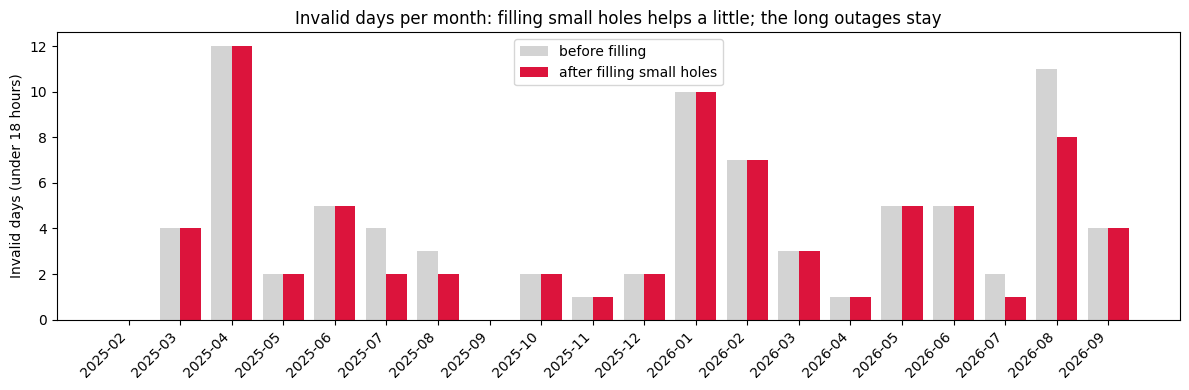

In [14]:
# 3.3 chart: invalid days per month, before vs after
import numpy as np

x = np.arange(len(invalid_by_month))
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - 0.2, invalid_by_month["before"], width=0.4, color="lightgray", label="before filling")
ax.bar(x + 0.2, invalid_by_month["after"], width=0.4, color="crimson", label="after filling small holes")
ax.set_xticks(x, invalid_by_month.index.astype(str), rotation=45, ha="right")
ax.set_title("Invalid days per month: filling small holes helps a little; the long outages stay")
ax.set_ylabel("Invalid days (under 18 hours)")
ax.legend()
plt.tight_layout()
plt.show()

### 3.4 to 3.6: the three "leave it" decisions with nothing to apply

- **Fault 4, wind and NOx start late.** We only load PM2.5, so there's nothing to change.
- **Diwali, 1,753.** Real smoke. We **prove** it survived: the biggest hour
  after cleaning must still be 1,753, at the same time.
- **One sensor.** Nothing is wrong.

Diwali peak still there: 1753.0 at 2025-10-21 03:00:00+05:30


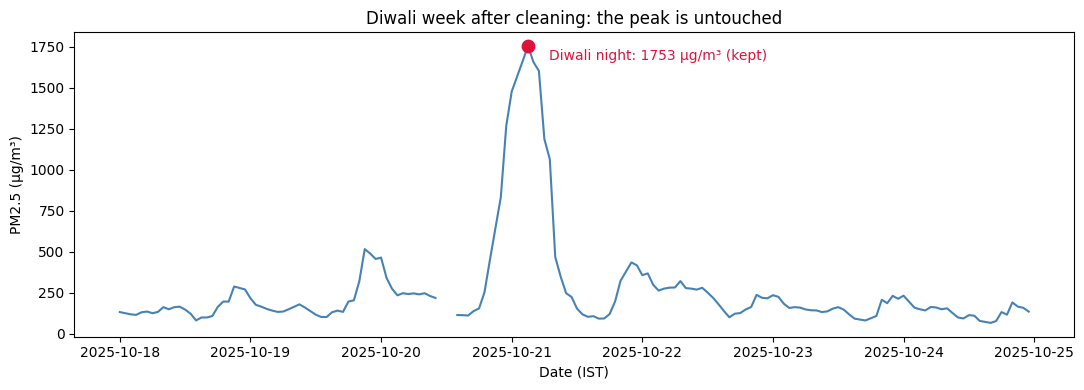

In [15]:
# 3.4 to 3.6: record the "leave it" decisions, and guard Diwali
decisions[3]["rows_changed"] = 0
decisions[4]["rows_changed"] = 0
decisions[5]["rows_changed"] = 0

# Diwali guard: cleaning must not touch the most important night
assert hourly_filled.max() == hourly.max() == 1753, "the Diwali peak changed"
assert hourly_filled.idxmax() == hourly.idxmax(), "the Diwali peak moved"
print("Diwali peak still there:", hourly_filled.max(), "at", hourly_filled.idxmax())

week = hourly_filled["2025-10-18":"2025-10-24"]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(week.index, week.values, color="steelblue")
ax.scatter([week.idxmax()], [week.max()], color="crimson", s=80, zorder=3)
ax.annotate(f"Diwali night: {week.max():.0f} µg/m³ (kept)", (week.idxmax(), week.max()),
            xytext=(15, -10), textcoords="offset points", color="crimson")
ax.set_title("Diwali week after cleaning: the peak is untouched")
ax.set_xlabel("Date (IST)")
ax.set_ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

### 3.7 Fault 7: the sensor misbehaves, 4–11 July 2025 (decision: mark the week invalid)

**How it was found.** Not in DAF-08. It showed up in Step 6, when the model
got slightly worse after cleaning. Tracing that back led to this week.

**What happened.** Real air changes smoothly, even on Diwali: 1,267 → 1,476
→ 1,753 → 1,656. This week it doesn't:

```text
9 Jul:   … 1, 31, 31, 34, 432, ?, 17, 13 …
11 Jul:  167, 729, 951, 116, ?, 19, 33, 138 …
```

1 → 432 → 17 in three hours, and 951 in monsoon July, is a broken sensor, not
smoke.

**How we measure it.** Compare every hour with the **median of the 7 hours
around it**. A median ignores one wild value, so it shows what "normal" was
right then. We flag an hour when it's more than **4×** that normal and above
200.

**Decision.** We don't try to repair single hours. If the sensor was wrong
at 10:00, the 1.0 at 05:00 can't be trusted either. So **every reading from
4 to 11 July 2025 is removed**. Those 8 days get 0 hours, so they're invalid
and are never used as a feature or a target. It's like an incident window at
work: a fixed date range, written down, whose data we exclude.

The spike rule is only used to **find** the week. The cleaning itself uses
the fixed dates in `BROKEN_SENSOR_DAYS`.

**Order matters.** The week is removed **before** filling holes. Otherwise a
hole next to a 951 would be filled with a guess made from 951.

In [16]:
# 3.7: find hours that are far above the hours around them
local_normal = hourly.rolling(7, center=True, min_periods=3).median()
spike = (hourly > 4 * local_normal) & (hourly > 200)

spikes = pd.DataFrame({"value": hourly[spike], "normal around it": local_normal[spike]}).round(0)
print("Spike hours in the whole span:", spike.sum())
print(spikes.to_string())

in_week = spikes.index.normalize().to_series().between(*[pd.Timestamp(d, tz=hourly.index.tz) for d in BROKEN_SENSOR_DAYS])
print(f"\nInside {BROKEN_SENSOR_DAYS[0]} to {BROKEN_SENSOR_DAYS[1]}: {in_week.sum()} of {len(spikes)}")
print("Diwali flagged?", (spikes.index.normalize() == pd.Timestamp("2025-10-21", tz=hourly.index.tz)).any())

Spike hours in the whole span: 12
                            value  normal around it
datetime                                           
2025-06-06 11:00:00+05:30   266.0              44.0
2025-07-04 17:00:00+05:30  1356.0              68.0
2025-07-04 18:00:00+05:30  1316.0              87.0
2025-07-05 08:00:00+05:30   701.0             123.0
2025-07-08 02:00:00+05:30   216.0              50.0
2025-07-08 10:00:00+05:30   575.0             116.0
2025-07-09 10:00:00+05:30   432.0              31.0
2025-07-10 02:00:00+05:30   230.0              38.0
2025-07-10 11:00:00+05:30   366.0              68.0
2025-07-11 01:00:00+05:30   729.0             156.0
2025-07-11 02:00:00+05:30   951.0             156.0
2025-07-11 10:00:00+05:30   668.0             138.0

Inside 2025-07-04 to 2025-07-11: 11 of 12
Diwali flagged? False


In [17]:
# 3.7: remove the broken week, THEN fill short holes (same logic as 3.2 B)
week_start = pd.Timestamp(BROKEN_SENSOR_DAYS[0], tz=hourly.index.tz)
week_end = pd.Timestamp(BROKEN_SENSOR_DAYS[1], tz=hourly.index.tz) + pd.Timedelta(days=1)   # end of the last day
broken = (hourly.index >= week_start) & (hourly.index < week_end)

hourly_trusted = hourly.mask(broken)
print("Hours removed (had a reading, now empty):", (hourly.notna() & broken).sum())
print("Days made invalid:", pd.Series(hourly.index[broken].normalize()).nunique())

# Fill short holes again, on the trusted hours
is_empty_t = hourly_trusted.isna()
run_id_t = (is_empty_t != is_empty_t.shift()).cumsum()
short_hole_t = is_empty_t & (is_empty_t.groupby(run_id_t).transform("sum") <= FILL_LIMIT_HOURS)
hourly_filled = hourly_trusted.where(~short_hole_t, hourly_trusted.interpolate(method="time", limit_area="inside"))

filled_hours = (hourly_trusted.isna() & hourly_filled.notna()).sum()
print("Hours filled (Fault 2), after removing the week:", filled_hours)
assert hourly_filled[broken].isna().all(), "a broken-week hour was filled"

decisions[1]["rows_changed"] = int(filled_hours)
decisions[6]["rows_changed"] = int((hourly.notna() & broken).sum())

Hours removed (had a reading, now empty): 144
Days made invalid: 8
Hours filled (Fault 2), after removing the week: 240


In [18]:
# The finished decision log: every fault has a treatment AND a counted number
decision_log = pd.DataFrame(decisions)
assert decision_log["rows_changed"].notna().all(), "a decision has no count"
decision_log[["fault", "treatment", "rows_changed"]]

,fault,treatment,rows_changed
0,1. 3 of 4 readings are copies,leave it,0
1,2. missing hours,fill small holes (up to 2 h),240
2,3. bad days come in groups,leave it,0
3,4. wind and nox start late,leave it,0
4,"5. Diwali 1,753 (not a fault)",leave it,0
5,6. one sensor (not a fault),leave it,0
6,"7. broken sensor week, 4-11 July 2025 (found i...",mark the week invalid,144


### Step 3 in one picture: one real day, start to end

Everything Step 3 did, shown on **one real day**: 1 August 2025 at R K Puram.
Read the picture from top to bottom; each panel is one small step.

![Step 3 walkthrough](figures/daf09_step3_walkthrough.png)

| Panel | What happens | The example |
|---|---|---|
| ① | **Raw file.** A reading every 15 minutes, 4 per hour. | 06:00 hour: 7, 7, 7, 7. 07:00 hour: nothing arrived. 08:00 hour: 39, 39, 39, 39. |
| ② | **Fault 1, the late hour.** Sometimes the new reading comes at :15, so :00 is still the old value. | 25 Mar 17:00: 34 (old), 29, 29, 29. Average 30.25, true value 29. Off by 1.25. On a whole day, at most ~2. **Leave it.** |
| ③ | **Average each hour** into one number. | 06:00 → 7. 07:00 → NaN (empty). 08:00 → 39. |
| ④ | **Find the holes** in the whole day, and measure each one. | 17 of 24 hours have a number. Hole at 07:00 is **1 hour** (≤ 2, fill). Hole 15:00–20:00 is **6 hours** (> 2, leave empty). |
| ⑤ | **Fill only the short hole** with a straight line. | (7 + 39) / 2 = **23**. |
| ⑥ | **Count the hours again** and apply the 18-hour rule. | 17 hours → invalid ✗. 18 hours → **valid** ✓. The 6-hour hole is still empty, on purpose. |

**In one line:** the copies (Fault 1) are left alone, one short hole gets a
straight-line guess (Fault 2), and that single guess turns this day from
invalid into valid. Across the whole dataset, 240 hours were filled
this way (after the broken week in 3.7 was removed first), turning 7 days valid.

## Step 4. Put all the decisions into one function

### Why?

In Step 3 the cleaning is spread over many cells. That's fine for
exploring, but it has two problems:

1. **Order can change.** If someone runs the cells in a different order, the
   result is different.
2. **It can't be reused.** In Phase 8 the live service must clean today's
   data **exactly** the same way. If it cleans even a little differently, the
   model gets numbers it never saw in training. Nothing crashes; the
   forecasts just quietly get worse.

So we put everything into **one function**. Same input, same steps, same
order, every time. It's like moving logic out of a controller into one
service method that everyone calls.

### What goes in, what comes out

```text
pm25_raw  (15-min readings)
    │
    ▼
┌──────────────────── clean_pm25() ────────────────────┐
│  1. Fault 1: leave the copies (nothing to do)         │
│  2. Average each hour  (same as DAF-05)               │
│  3. Fault 7: remove the broken week (4–11 Jul 2025)   │
│  4. Fault 2: fill holes of 1–2 hours only             │
│  Faults 3–6: leave it (nothing to do)                 │
└───────────────────────────────────────────────────────┘
    │
    ▼
hourly_clean  (one number per hour, short holes filled)
```

### Three rules the function follows

- **It never changes its input.** `pm25_raw` stays as it was.
- **No numbers learned from the data.** No average, standard deviation or
  percentile of the whole table. The only settings are `FILL_LIMIT_HOURS = 2` and
  the broken-week dates, both chosen by hand. So it can't leak anything from the test period.
- **Each fault is one small helper.** Faults with "leave it" don't need code;
  a comment in the function records the decision.

In [19]:
# Step 4: every DAF-09 decision in one place, in a fixed order

def fill_short_holes(hourly, max_hours):
    """Fill holes of max_hours or shorter with a straight line. Longer holes stay empty."""
    is_empty = hourly.isna()
    run_id = (is_empty != is_empty.shift()).cumsum()                 # a new id each time empty/full switches
    hole_length = is_empty.groupby(run_id).transform("sum")           # every empty hour knows its hole's length
    short_hole = is_empty & (hole_length <= max_hours)

    straight_line = hourly.interpolate(method="time", limit_area="inside")
    return hourly.where(~short_hole, straight_line)                   # use the guess only inside short holes


def remove_days(hourly, first_day, last_day):
    """Blank every hour from first_day to last_day (both included)."""
    start = pd.Timestamp(first_day, tz=hourly.index.tz)
    end = pd.Timestamp(last_day, tz=hourly.index.tz) + pd.Timedelta(days=1)
    return hourly.mask((hourly.index >= start) & (hourly.index < end))


def clean_pm25(pm25_raw, fill_limit_hours=FILL_LIMIT_HOURS, broken_days=BROKEN_SENSOR_DAYS):
    """15-min PM2.5 readings -> cleaned hourly series. Does not change pm25_raw."""
    readings = pm25_raw.set_index("datetime")["value"].sort_index()   # a new object; pm25_raw is untouched

    # Fault 1 (copies inside an hour): leave it. The hourly average below handles them.

    # Average each hour, exactly as DAF-05 step 3
    hourly = readings.resample("1h").mean()

    # Fault 7 (broken sensor week): remove it BEFORE filling, so no guess is made from a bad reading
    hourly = remove_days(hourly, *broken_days)

    # Fault 2 (missing hours): fill holes of 1-2 hours only
    hourly = fill_short_holes(hourly, fill_limit_hours)

    # Fault 3 (bad days in groups), Fault 4 (wind starts late),
    # Diwali, one sensor: leave it. Nothing to apply.
    return hourly

### Check the function

A function is only useful if we can trust it. Four checks:

| Check | Why |
|---|---|
| Same answer as Step 3 | The function must do exactly what Step 3 did, nothing more |
| `pm25_raw` unchanged | Rule 1: never change the input |
| Run twice, same answer | Same input must always give the same output |
| Diwali peak still 1,753 | Cleaning must never touch the most important night |

In [20]:
# Run it once
pm25_raw_before = pm25_raw.copy()
hourly_clean = clean_pm25(pm25_raw)

print("Hourly slots:", len(hourly_clean))
print("Empty hours before cleaning:", hourly.isna().sum())
print("Empty hours after cleaning :", hourly_clean.isna().sum())

# 1. Same answer as Step 3
pd.testing.assert_series_equal(hourly_clean, hourly_filled, check_names=False)
print("\n✅ Same result as Step 3")

# 2. The input is unchanged
pd.testing.assert_frame_equal(pm25_raw, pm25_raw_before)
print("✅ pm25_raw unchanged")

# 3. Run twice, same answer
pd.testing.assert_series_equal(clean_pm25(pm25_raw), hourly_clean)
print("✅ Same answer every run")

# 4. Diwali untouched
assert hourly_clean.max() == 1753 and hourly_clean.idxmax() == hourly.idxmax()
print("✅ Diwali peak still", hourly_clean.max(), "at", hourly_clean.idxmax())

Hourly slots: 13680
Empty hours before cleaning: 1515
Empty hours after cleaning : 1419

✅ Same result as Step 3
✅ pm25_raw unchanged
✅ Same answer every run
✅ Diwali peak still 1753.0 at 2025-10-21 03:00:00+05:30


## Step 5. Rebuild the daily table, exactly as DAF-05

### What we do

We take `hourly_clean` from Step 4 and turn it into **one row per day**,
with the same columns and rules as DAF-05:

| Column | Meaning |
|---|---|
| `pm25_mean` | average of the day's hours |
| `hours` | how many hours have a number |
| `pm25_until_17` | average of hours 00:00–17:00 (what Asha knows at 18:00) |
| `valid` | `hours >= 18` |
| `target` | tomorrow's `pm25_mean`, only if tomorrow is valid |

**The rule: change only the input, never the recipe.** If we change both the
data and the recipe, we can't tell which one moved the MAE.

To prove the recipe is really the same, we first run it on the **uncleaned**
hourly data. The result must match `daily_17.csv` exactly.

In [21]:
# Step 5a: the DAF-05 recipe as one function

def build_daily(hourly, hourly_until_17=None):
    """Hourly PM2.5 -> one row per day, with the DAF-05 columns and rules.
    hourly_until_17: the hours to use for pm25_until_17 (default: the same hourly series)."""
    if hourly_until_17 is None:
        hourly_until_17 = hourly

    until_17 = hourly_until_17[hourly_until_17.index.hour <= 17]
    daily = pd.DataFrame({
        "pm25_mean": hourly.resample("D").mean(),
        "hours": hourly.resample("D").count(),
        "pm25_until_17": until_17.resample("D").mean(),
    })
    daily["valid"] = daily["hours"] >= 18

    # gap-free calendar, so "next row" really is "next day"
    full_range = pd.date_range(daily.index.min(), daily.index.max(), freq="D", tz=daily.index.tz)
    daily = daily.reindex(full_range)
    daily["valid"] = daily["valid"].fillna(False).astype(bool)

    # target = tomorrow's mean, only when tomorrow is valid
    next_day_valid = daily["valid"].shift(-1, fill_value=False)
    daily["target"] = daily["pm25_mean"].shift(-1).where(next_day_valid)
    return daily


# Proof: the recipe on UNCLEANED hours must give back daily_17.csv exactly
interim_dir = project_root / "data/interim"
daily_before = pd.read_csv(interim_dir / "daily_17.csv", parse_dates=["date"], index_col="date")

rebuilt = build_daily(hourly)
pd.testing.assert_frame_equal(rebuilt, daily_before, check_names=False, check_freq=False)
print("✅ build_daily(uncleaned hours) matches daily_17.csv exactly:", rebuilt.shape)

✅ build_daily(uncleaned hours) matches daily_17.csv exactly: (571, 5)


### One catch: don't use the future for `pm25_until_17`

`pm25_until_17` is what Asha knows **at 18:00**. Look at this real kind of
hole:

```text
16:00 → 40     17:00 → ???     18:00 → 60
                  │
     straight line says 50, but it needs the 18:00 reading
```

At 18:00 in real life, the 18:00 hour hasn't finished yet, so this hole
**can't** be filled; there's no reading after it. If training fills it
anyway, the model learns from a number the live service can never have.
That's a small leak from the future.

**The fix:** for `pm25_until_17` only, don't use a filled hour whose hole
ends at 16:00 or 17:00 (because its right neighbour is 18:00 or later). Every
other fill is fine: its neighbours are both in the past. For `pm25_mean` and
`hours` (the full day, and so the target) all fills are used, because the
full day is over by then.

In [22]:
# Step 5b: hours Asha could really know at 18:00

def hours_known_at_18(hourly_raw, hourly_clean):
    """hourly_clean, minus filled hours that needed a reading from 18:00 or later that same day."""
    is_empty = hourly_raw.isna()
    run_id = (is_empty != is_empty.shift()).cumsum()
    hole_end = pd.Series(hourly_raw.index, index=hourly_raw.index).groupby(run_id).transform("max")
    right_neighbour_hour = (hole_end + pd.Timedelta(hours=1)).dt.hour

    was_filled = is_empty & hourly_clean.notna()
    needs_evening = was_filled & (hourly_raw.index.hour <= 17) & (right_neighbour_hour >= 18)
    print("Filled hours that needed an evening reading:", needs_evening.sum(),
          "on", needs_evening[needs_evening].index.normalize().nunique(), "days")
    return hourly_clean.mask(needs_evening)


hourly_at_18 = hours_known_at_18(hourly, hourly_clean)

daily_clean = build_daily(hourly_clean, hourly_until_17=hourly_at_18)
daily_clean.to_csv(interim_dir / "daily_17_clean.csv", index_label="date")

print("\nSaved:", interim_dir / "daily_17_clean.csv", daily_clean.shape)
print("daily_17.csv is untouched: the DAF-07 result was built from it")

Filled hours that needed an evening reading: 18 on 16 days

Saved: /Users/kaliprasad/Documents/MACHINE_LEARNING/18_Projects/01_Delhi_Air_Forecast/data/interim/daily_17_clean.csv (571, 5)
daily_17.csv is untouched: the DAF-07 result was built from it


### Did cleaning remove any bad-air days?

This is the question Asha cares about most. Cleaning is only safe if
**Poor-or-worse days (91 µg/m³ or more) don't go down.**

We count two kinds:
- by `pm25_mean`: days that **were** Poor
- by `target`: Poor days the model is **scored** on (recall)

A total can hide things: one day can drop out while another comes in. So we
also list **every day that crossed the 91 line**, in either direction.

In [23]:
# Step 5c: before vs after
POOR = 91

def summary(daily):
    return pd.Series({
        "days": len(daily),
        "valid days": int(daily["valid"].sum()),
        "usable targets": int(daily["target"].notna().sum()),
        "Poor days (pm25_mean >= 91)": int((daily["pm25_mean"] >= POOR).sum()),
        "Poor days, valid only": int(((daily["pm25_mean"] >= POOR) & daily["valid"]).sum()),
        "Poor targets (target >= 91)": int((daily["target"] >= POOR).sum()),
    })

before_after = pd.DataFrame({"before": summary(daily_before), "after": summary(daily_clean)})
before_after["change"] = before_after["after"] - before_after["before"]
print(before_after.to_string())

# Which days changed their pm25_until_17, and by how much?
until_17_change = (daily_clean["pm25_until_17"] - daily_before["pm25_until_17"]).abs()
print(f"\nDays where pm25_until_17 changed: {(until_17_change > 1e-9).sum()}"
      f"  (largest change {until_17_change.max():.2f} µg/m³)")

# Every day that crossed the Poor line, in either direction
was_poor = daily_before["pm25_mean"] >= POOR
is_poor = daily_clean["pm25_mean"] >= POOR
crossed = pd.DataFrame({
    "before": daily_before["pm25_mean"], "after": daily_clean["pm25_mean"],
    "hours before": daily_before["hours"], "hours after": daily_clean["hours"],
})[was_poor != is_poor].round(2)
in_broken_week = daily_before.index.to_series().between(
    pd.Timestamp(BROKEN_SENSOR_DAYS[0], tz=daily_before.index.tz), pd.Timestamp(BROKEN_SENSOR_DAYS[1], tz=daily_before.index.tz))
crossed["in broken week"] = in_broken_week[crossed.index]
print("\nDays that crossed the Poor line (pm25_mean, 91):")
print(crossed.to_string())

# Acceptance check: outside the broken week, cleaning must not DELETE a Poor day.
# (A day can still move across the line because its average got more honest; those are listed above.)
real_poor_gone = was_poor & daily_clean["pm25_mean"].isna() & ~in_broken_week
assert not real_poor_gone.any(), "cleaning deleted a real Poor day"
print("\n✅ No real Poor day was deleted; every crossing is listed above")

                             before  after  change
days                            571    571       0
valid days                      488    488       0
usable targets                  487    487       0
Poor days (pm25_mean >= 91)     173    168      -5
Poor days, valid only           156    152      -4
Poor targets (target >= 91)     156    152      -4

Days where pm25_until_17 changed: 134  (largest change 105.22 µg/m³)

Days that crossed the Poor line (pm25_mean, 91):
                           before  after  hours before  hours after  in broken week
2025-07-04 00:00:00+05:30  186.90    NaN            20            0            True
2025-07-05 00:00:00+05:30  171.38    NaN            21            0            True
2025-07-08 00:00:00+05:30   99.95    NaN            21            0            True
2025-07-11 00:00:00+05:30  226.47    NaN            15            0            True
2026-04-17 00:00:00+05:30   93.45  89.96            22           24           False

✅ No real Poor day

### What Step 5 shows

- **The recipe is the same as DAF-05.** On uncleaned hours it gives back
  `daily_17.csv` exactly.
- **Valid days: 488 → 488.** Filling small holes made 7 days valid.
  Removing the broken sensor week (Fault 7) made 7 days invalid. They cancel
  out, but they are **different days**.
- **Poor days: 173 → 168.** Every one of the 5 is listed above:
  - **4 are fake**, from the broken week (4, 5, 8, 11 July 2025). Their high
    averages came from readings like 1,356 and 951.
  - **1 is real but more honest**: 17 April 2026 dropped from 93.45 to 89.96.
    Its missing hours were in a clean evening (between 46 and 57), so
    leaving them out made the day look worse than it was.
- **No real Poor day was deleted.** The only Poor days that vanished are
  inside the broken week.
- **`pm25_until_17` moved on 134 days**, mostly by less than 1 µg/m³. The
  biggest is **Diwali morning, 21 Oct 2025**: 01:00 and 02:00 were missing
  between 1,476 and 1,753. Filling them raises the morning average from 668
  to 773. Cleaning brings back the peak instead of hiding it.
- **18 fills were kept out of `pm25_until_17`**, because they needed a
  reading from 18:00 or later that Asha doesn't have at 18:00.

### Step 5 in one picture: from cleaned hours to the daily table

We follow the same day as Step 3, **1 August 2025**, from its cleaned hours
to its row in `daily_17_clean.csv`.

![Step 5 walkthrough](figures/daf09_step5_walkthrough.png)

| Panel | What happens | The example |
|---|---|---|
| ① | **Start with the cleaned hours** from Step 3. | 18 of 24 hours have a number. 07:00 was filled (23). 15:00–20:00 stay empty. Hours 00:00–17:00 are what Asha knows at 18:00. |
| ② | **Squash the day into one row** with the DAF-05 recipe. | `pm25_mean` 32.06 → **31.56** · `hours` 17 → **18** · `pm25_until_17` 34.71 → **33.93** · `valid` False → **True** |
| ③ | **`target` = tomorrow's `pm25_mean`**, written on **today's** row, only if tomorrow is valid. | Before: 1 Aug was invalid, so **31 Jul had no target**. After: 31 Jul gets target **31.56** (1 Aug's mean). That's **+1 usable row** for the model. (31 Jul's own mean moved a little too, 35.43 → 34.81, because it also had a 1-hour hole that was filled.) |
| ④ | **The catch:** a hole touching 17:00 can only be filled with a reading **after** 18:00. | 2 Jul: 17:00 and 18:00 missing. The fill 17.7 needs the 19:00 reading, so it is **not** used for `pm25_until_17`. It **is** used for the full day (`hours` 22 → 24). |
| ⑤ | **Do it for all 571 days and count.** | Valid days 488 → 488 (+7 filled, −7 broken week). Poor days 173 → **168**: 4 fake days from the broken week, plus 17 Apr 2026 (93.5 → 90.0, a more honest average). Poor targets 156 → **152**. |

**In one line:** the recipe is the same as DAF-05. Only the input got
cleaner. Some days became usable, the broken week dropped out, no real
bad-air day was deleted, and no number Asha couldn't know at 18:00 slipped
into `pm25_until_17`.

## Step 6. Run the DAF-07 model again, on the cleaned table

### What we do

We use the **exact same model** as DAF-07 and change only the table:

| Kept the same | Value |
|---|---|
| Features | `pm25_until_17`, `lag_1`, `mean_3`, `mean_7`, `month` |
| Model | `Pipeline(StandardScaler → Ridge(alpha=1.0))` |
| Cut date | train before **2026-03-01**, test from 2026-03-01 |
| Poor line | **91** µg/m³ |

| Changed | |
|---|---|
| Table | `daily_17.csv` → `daily_17_clean.csv` |

### First, a safety check

We write the DAF-07 steps as one function and run it on the **old** table
first. It must give DAF-07's numbers back: **MAE 15.507, recall 0.353, 145
test days**. If it doesn't, our copy of DAF-07 is wrong, and any comparison
after it is meaningless.

In [24]:
# Step 6a: DAF-07 as one function
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

FEATURES = ["pm25_until_17", "lag_1", "mean_3", "mean_7", "month"]
CUT_DATE = pd.Timestamp("2026-03-01", tz=daily_before.index.tz)


def make_features(daily):
    """Same features as DAF-07 section 2. Rows with anything missing are dropped."""
    yesterday = daily["pm25_mean"].shift(1)
    table = pd.DataFrame(index=daily.index)
    table["pm25_until_17"] = daily["pm25_until_17"]
    table["lag_1"] = yesterday
    table["mean_3"] = yesterday.rolling(3).mean()
    table["mean_7"] = yesterday.rolling(7).mean()
    table["month"] = daily.index.month
    table["target"] = daily["target"]
    return table.dropna()


def run_daf07(daily):
    """Split at CUT_DATE, fit on train, return test rows with the actual value and Ridge's guess."""
    rows = make_features(daily)
    train, test = rows[rows.index < CUT_DATE], rows[rows.index >= CUT_DATE]
    pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge())])
    pipe.fit(train[FEATURES], train["target"])
    result = pd.DataFrame({"actual": test["target"], "ridge": pipe.predict(test[FEATURES])}, index=test.index)
    return result, len(train)


def score(actual, guess):
    """MAE and the Poor-day boxes, same logic as DAF-07."""
    poor, warned = actual >= POOR, guess >= POOR
    caught, missed = (poor & warned).sum(), (poor & ~warned).sum()
    return {"days": len(actual), "mae": mean_absolute_error(actual, guess),
            "poor_days": int(poor.sum()), "caught": int(caught), "missed": int(missed),
            "false_alarms": int((~poor & warned).sum()), "recall_poor": caught / (caught + missed)}


# Safety check: on the OLD table we must get DAF-07's numbers back
result_before, train_rows_before = run_daf07(daily_before)
check = score(result_before["actual"], result_before["ridge"])
print(f"Old table → train {train_rows_before}, test {check['days']}, "
      f"MAE {check['mae']:.3f}, recall {check['recall_poor']:.3f}")
assert check["days"] == 145 and round(check["mae"], 3) == 15.507 and round(check["recall_poor"], 3) == 0.353
print("✅ Same as DAF-07: our copy of the model is exact")

Old table → train 283, test 145, MAE 15.507, recall 0.353
✅ Same as DAF-07: our copy of the model is exact


### Now the cleaned table, and a fair comparison

Cleaning made more days valid, so the cleaned table has **more test days**
than DAF-07's 145. Comparing a score on 150 days with a score on 145 days is
not fair: the extra days might just be easier or harder.

```text
old test days    ●●●●●●●●●●●●●●●  145
new test days    ●●●●●●●●●●●●●●●●●  more
                 └─── common ───┘   score BOTH models on these days
```

So we report two things:

1. **All new test days**: what the cleaned model can do now.
2. **Common days only**: the fair question. On the **same** days, did
   cleaning help?

In [25]:
# Step 6b: the cleaned table
result_after, train_rows_after = run_daf07(daily_clean)
print(f"Train rows: {train_rows_before} → {train_rows_after}")
print(f"Test rows : {len(result_before)} → {len(result_after)}")

# The days both runs were tested on
common = result_before.index.intersection(result_after.index)
print(f"Common test days: {len(common)}")
print(f"Only in the new test: {len(result_after.index.difference(result_before.index))} days")
print(f"Only in the old test: {len(result_before.index.difference(result_after.index))} days")

# Did the ACTUAL answer change on common days? (cleaning can change the target too)
target_moved = (result_before.loc[common, "actual"] - result_after.loc[common, "actual"]).abs()
print(f"Common days whose actual target changed: {(target_moved > 1e-9).sum()}")

scores = pd.DataFrame({
    "DAF-07, old table (145 days)": score(result_before["actual"], result_before["ridge"]),
    "DAF-09, cleaned table (all test days)": score(result_after["actual"], result_after["ridge"]),
    "DAF-07 on common days": score(result_before.loc[common, "actual"], result_before.loc[common, "ridge"]),
    "DAF-09 on common days": score(result_after.loc[common, "actual"], result_after.loc[common, "ridge"]),
    "DAF-09 on common days, OLD answer key": score(result_before.loc[common, "actual"], result_after.loc[common, "ridge"]),
}).T
print()
print(scores.to_string(float_format=lambda v: f"{v:.3f}"))

Train rows: 283 → 272
Test rows : 145 → 148
Common test days: 145
Only in the new test: 3 days
Only in the old test: 0 days
Common days whose actual target changed: 61

                                         days    mae  poor_days  caught  missed  false_alarms  recall_poor
DAF-07, old table (145 days)          145.000 15.507     17.000   6.000  11.000         7.000        0.353
DAF-09, cleaned table (all test days) 148.000 15.963     16.000   7.000   9.000         6.000        0.438
DAF-07 on common days                 145.000 15.507     17.000   6.000  11.000         7.000        0.353
DAF-09 on common days                 145.000 15.853     16.000   7.000   9.000         6.000        0.438
DAF-09 on common days, OLD answer key 145.000 15.838     17.000   7.000  10.000         6.000        0.412


### What Step 6 shows

| | DAF-07 (old table) | DAF-09 (cleaned) | Change |
|---|---|---|---|
| Train days | 283 | 272 | −11 (broken week, and the days whose `mean_7` needs it) |
| Test days | 145 | 148 | +3 (days made valid by filling) |

**The fair comparison:** the same 145 days, scored against the **same**
answer (the old, measured-only target):

| | MAE | Poor days caught | Missed | False alarms | Recall |
|---|---|---|---|---|---|
| DAF-07 | **15.507** | 6 of 17 | 11 | 7 | 0.353 |
| DAF-09 | 15.838 | **7 of 17** | **10** | **6** | **0.412** |

**In simple words:**

- **MAE went up by 0.33 µg/m³ (about 2%).** That is tiny: a third of a
  µg/m³ on an average error of 15.5. It's too small to be sure it's a real
  change. What we **can** say is that cleaning **didn't make it better**.
- **One more Poor day caught, one fewer false alarm.** For Asha a warning
  matters more than a small average error. But one day out of 17 is also
  too small to call a real win.
- **Honest summary: cleaning barely moved the model.** That is a useful
  answer, not a failure. The ticket says so: if the MAE doesn't move, the
  faults didn't matter much for this model. The bigger gains will have to
  come from better features (weather, DAF-12 to DAF-14), not from cleaning.

**Why train days dropped by 11, not 8.** Removing the 8 broken days also
breaks `lag_1`, `mean_3` and `mean_7` for the few days right after the week,
because those features look back at the missing days.

### Step 6 in one picture: the same model, on the old and the cleaned table

![Step 6 walkthrough](figures/daf09_step6_walkthrough.png)

| Panel | What happens | The example |
|---|---|---|
| ① | **Same model, two tables.** `run_daf07()` is DAF-07 in one function. Only the input table changes. | `daily_17.csv` and `daily_17_clean.csv` both go through the same features, the same Ridge and the same cut date. |
| ② | **Safety check.** The old table must give DAF-07's numbers back. | 145 test days, MAE 15.507, recall 0.353 = DAF-07 ✓ |
| ③ | **Every day and what it's used for.** Blue = train, orange = test, gray = can't be used. | Old: 283 train, 145 test. Cleaned: 272 train, 148 test. |
| ④ | **Why train lost 11 days**, zoomed on July 2025. | Lost 12: 4–11 Jul are the broken week; 12–18 Jul lose `mean_7`, which looks back 7 days into the removed week; 3 Jul loses its target, because its tomorrow was removed. Gained 1: 31 Jul, because 1 Aug became valid (Step 5). 12 − 1 = **11**. |
| ⑤ | **A fair race.** Both models are scored on the same 145 days, with the same answer. | The 3 extra days (8 Jul, 5 Aug, 6 Aug 2026) are left out of the comparison. |
| ⑥ | **Where the recall change comes from.** Only 2 days changed, both right on the 91 line. | **26 Apr** (really 102.5): DAF-07 guessed 90.0, missed; DAF-09 guessed 91.1, caught. **22 Apr** (really 67.7): DAF-07 guessed 91.8, a false alarm; DAF-09 guessed 90.9, no alarm. Each moved about 1 µg/m³. |
| ⑦ | **Scoreboard.** | MAE 15.507 → 15.838 · caught 6 → 7 · false alarms 7 → 6 · recall 0.353 → 0.412 |

**In one line:** cleaning barely moved the model. The recall gain is two
guesses that slid about 1 µg/m³ across the 91 line, and the MAE change is a
third of a µg/m³. Both are too small to call. Bigger gains must come from new
features, not more cleaning.

## Step 7. Write the result into the experiment log

### Why?

`reports/experiments.csv` is the project's memory: one row per experiment.
Weeks from now, nobody will re-run this notebook to remember what cleaning
did. They'll read this file. Think of it like a changelog, but for model
results.

### What goes in the row

| Column | Value | Why this one |
|---|---|---|
| `mae`, `recall_poor` | the cleaned model on **all 148** cleaned test days | From now on `daily_17_clean.csv` is the table every later ticket builds on, so this is the new number to beat |
| `notes` | the **fair** comparison: same 145 days, same answer | So a reader can see at once that cleaning barely moved the model |

The new row goes right under the DAF-07 row, so the two can be read side by
side.

### One safety rule

Running the cell twice must **not** add a second DAF-09 row. So the cell
first checks whether a DAF-09 row is already there. It's like an idempotent
API call at work: calling it again changes nothing.

In [26]:
# Step 7: add ONE DAF-09 row to the experiment log (safe to run again)
log_path = project_root / "reports/experiments.csv"
log = pd.read_csv(log_path)

all_days = scores.loc["DAF-09, cleaned table (all test days)"]
fair_07 = scores.loc["DAF-07 on common days"]
fair_09 = scores.loc["DAF-09 on common days, OLD answer key"]

new_row = {
    "ticket": "DAF-09",
    "date": "2026-09-23",
    "model": "ridge_pipeline",
    "features": "pm25_until_17, lag_1, mean_3, mean_7, month",
    "mae": round(all_days["mae"], 3),
    "recall_poor": round(all_days["recall_poor"], 3),
    "notes": (
        f"cleaned table daily_17_clean.csv: fill holes <= {FILL_LIMIT_HOURS} h, "
        f"broken sensor week {BROKEN_SENSOR_DAYS[0]} to {BROKEN_SENSOR_DAYS[1]} removed; "
        f"StandardScaler+Ridge(alpha=1.0), cut 2026-03-01; "
        f"{train_rows_after} train / {int(all_days['days'])} test rows; "
        f"{int(all_days['poor_days'])} Poor days (caught {int(all_days['caught'])}, "
        f"missed {int(all_days['missed'])}, false alarms {int(all_days['false_alarms'])}); "
        f"fair check on the same {int(fair_07['days'])} days and answer key: "
        f"MAE {fair_07['mae']:.3f} -> {fair_09['mae']:.3f}, recall {fair_07['recall_poor']:.3f} -> {fair_09['recall_poor']:.3f} "
        f"(2 days on the 91 line); cleaning barely moved the model"
    ),
}
assert list(new_row) == list(log.columns), "columns must match the log exactly"

if (log["ticket"] == "DAF-09").any():
    print("A DAF-09 row is already in the log; nothing added.")
else:
    pd.DataFrame([new_row]).to_csv(log_path, mode="a", header=False, index=False)
    print("Added the DAF-09 row.")

# Show DAF-07 and DAF-09 side by side
log = pd.read_csv(log_path)
print()
print(log[log["ticket"].isin(["DAF-07", "DAF-09"])][["ticket", "model", "mae", "recall_poor"]].to_string(index=False))
assert (log["ticket"] == "DAF-09").sum() == 1, "there must be exactly one DAF-09 row"

A DAF-09 row is already in the log; nothing added.

ticket          model    mae  recall_poor
DAF-07 ridge_pipeline 15.507        0.353
DAF-09 ridge_pipeline 15.963        0.438


## Step 8. Final checks: the acceptance criteria as `assert`s

### Why?

The ticket has five acceptance criteria. Instead of saying "I think it's
done", we turn each one into an `assert`. If any is false, the notebook
stops with a clear error. These are the unit tests of the ticket.

| # | Acceptance criterion | How we check it |
|---|---|---|
| 1 | Every fault in `docs/data_faults.md` has a decision, including "leave it" | Read the doc; every `## Fault …` and `## Not a fault …` section must contain a **Decision (DAF-09)** paragraph |
| 2 | Each decision says how many rows it changed | Every row of our decision log has a whole number in `rows_changed`, and every doc decision says "Rows changed" |
| 3 | `data/raw/` is unchanged | Fingerprint every raw file again and compare with Step 1 |
| 4 | Poor days counted before **and** after cleaning | The Step 5 table has both columns, and every day that crossed the line is listed |
| 5 | Re-scored MAE and recall are in the log, next to the pre-cleaning row | `experiments.csv` has one DAF-07 row and one DAF-09 row |

Plus one extra guard: **the Diwali peak is untouched.**

In [27]:
# Step 8: every acceptance criterion as an assert
import re

# 1. Every fault in the doc has a decision
faults_doc = (project_root / "docs/data_faults.md").read_text()
sections = re.split(r"\n## ", faults_doc)
fault_sections = [s for s in sections if s.startswith(("Fault", "Not a fault"))]
missing = [s.splitlines()[0] for s in fault_sections if "**Decision (DAF-09)" not in s]
assert not missing, f"no decision for: {missing}"
print(f"✅ 1. All {len(fault_sections)} sections in data_faults.md have a DAF-09 decision")

# 2. Each decision states how many rows it changed
assert all(isinstance(d["rows_changed"], int) for d in decisions), "a decision has no count"
no_count = [s.splitlines()[0] for s in fault_sections if "Rows changed" not in s.split("**Decision (DAF-09)")[1]]
assert not no_count, f"doc decision without a count: {no_count}"
assert len(decisions) == len(fault_sections), "the notebook log and the doc list different faults"
print(f"✅ 2. All {len(decisions)} decisions state rows changed:",
      {d["fault"].split(".")[0]: d["rows_changed"] for d in decisions})

# 3. data/raw is unchanged
files_now = sorted(raw_dir.rglob("*.csv.gz"))
raw_fingerprint_after = {
    str(f.relative_to(raw_dir)): hashlib.md5(f.read_bytes()).hexdigest() for f in files_now
}
assert raw_fingerprint_after == raw_fingerprint_before, "a raw file was added, removed or changed"
print(f"✅ 3. data/raw unchanged: {len(raw_fingerprint_after)} files, every fingerprint identical")

# 4. Poor days counted before and after
assert {"before", "after"} <= set(before_after.columns)
assert "Poor days (pm25_mean >= 91)" in before_after.index
print("✅ 4. Poor days counted: {} before, {} after; {} crossings listed in Step 5".format(
    before_after.loc["Poor days (pm25_mean >= 91)", "before"],
    before_after.loc["Poor days (pm25_mean >= 91)", "after"], len(crossed)))

# 5. The experiment log has the before and after rows
log = pd.read_csv(project_root / "reports/experiments.csv")
assert (log["ticket"] == "DAF-07").sum() == 1 and (log["ticket"] == "DAF-09").sum() == 1
print("✅ 5. experiments.csv: DAF-07 row (MAE {:.3f}) and DAF-09 row (MAE {:.3f})".format(
    log.loc[log["ticket"] == "DAF-07", "mae"].iloc[0], log.loc[log["ticket"] == "DAF-09", "mae"].iloc[0]))

# Extra guard: Diwali
assert hourly_clean.max() == 1753 and hourly_clean.idxmax() == pd.Timestamp("2025-10-21 03:00", tz=hourly_clean.index.tz)
print("✅ Diwali peak untouched: 1,753 at 2025-10-21 03:00")

print("\nAll acceptance criteria pass.")
pd.DataFrame(decisions)[["fault", "treatment", "rows_changed"]]

✅ 1. All 7 sections in data_faults.md have a DAF-09 decision
✅ 2. All 7 decisions state rows changed: {'1': 0, '2': 240, '3': 0, '4': 0, '5': 0, '6': 0, '7': 144}
✅ 3. data/raw unchanged: 554 files, every fingerprint identical
✅ 4. Poor days counted: 173 before, 168 after; 5 crossings listed in Step 5
✅ 5. experiments.csv: DAF-07 row (MAE 15.507) and DAF-09 row (MAE 15.963)
✅ Diwali peak untouched: 1,753 at 2025-10-21 03:00

All acceptance criteria pass.


,fault,treatment,rows_changed
0,1. 3 of 4 readings are copies,leave it,0
1,2. missing hours,fill small holes (up to 2 h),240
2,3. bad days come in groups,leave it,0
3,4. wind and nox start late,leave it,0
4,"5. Diwali 1,753 (not a fault)",leave it,0
5,6. one sensor (not a fault),leave it,0
6,"7. broken sensor week, 4-11 July 2025 (found i...",mark the week invalid,144
